## Embedded Patches


In [ ]:
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"

In [ ]:
device

'cuda'

In [ ]:
def to_rgb(image):
  return image.convert("RGB")

In [ ]:
img_size = 224
seed = 42

train_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.RandomResizedCrop(img_size, scale=(0.6, 0.99), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.33),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast = 0.2, saturation=0.2, hue = 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15), ratio=(0.3, 3.3), value="random", inplace=False)
])

test_tf = transforms.Compose([
    transforms.Lambda(to_rgb),
    transforms.Resize(256),     # aspect ratio korunsun diye 256 (en-boy oranı)
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import random_split
root = "./data"
test_ratio = 0.2

In [ ]:
ds_train_full = datasets.Caltech101(root=root, download=True, transform=train_tf)
ds_test_full = datasets.Caltech101(root=root, download=True, transform=test_tf)

100%|██████████| 137M/137M [00:01<00:00, 72.7MB/s]


In [ ]:
n_total = len(ds_train_full)
n_test = int(n_total * test_ratio)
n_train = n_total - n_test

In [ ]:
g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_total, generator = g).tolist()

In [ ]:
train_idx = perm[:n_train]
test_idx = perm[n_train:]

In [ ]:
train_ds = Subset(ds_train_full, train_idx)
test_ds = Subset(ds_test_full, test_idx)

In [ ]:
len(train_ds), len(test_ds)

(6942, 1735)

In [ ]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print(ds_train_full.categories)

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

In [ ]:
len(ds_train_full.categories)

101

In [ ]:

class_names = ds_train_full.categories
random_index = torch.randint(0, len(ds_train_full), (1,)).item()
img, label = ds_train_full[random_index]
print("Label: ", label)
print("Class name: ", class_names[label])

Label:  2
Class name:  Leopards


In [ ]:
image, label = train_dataloader.dataset[4]
image.shape, label

(torch.Size([3, 224, 224]), 50)

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

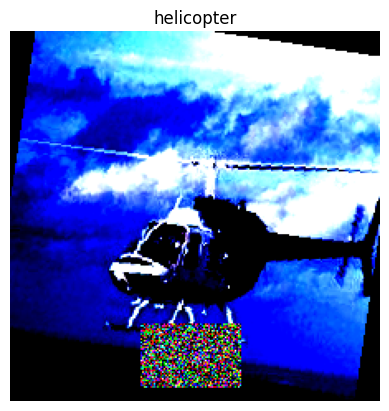

In [ ]:
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


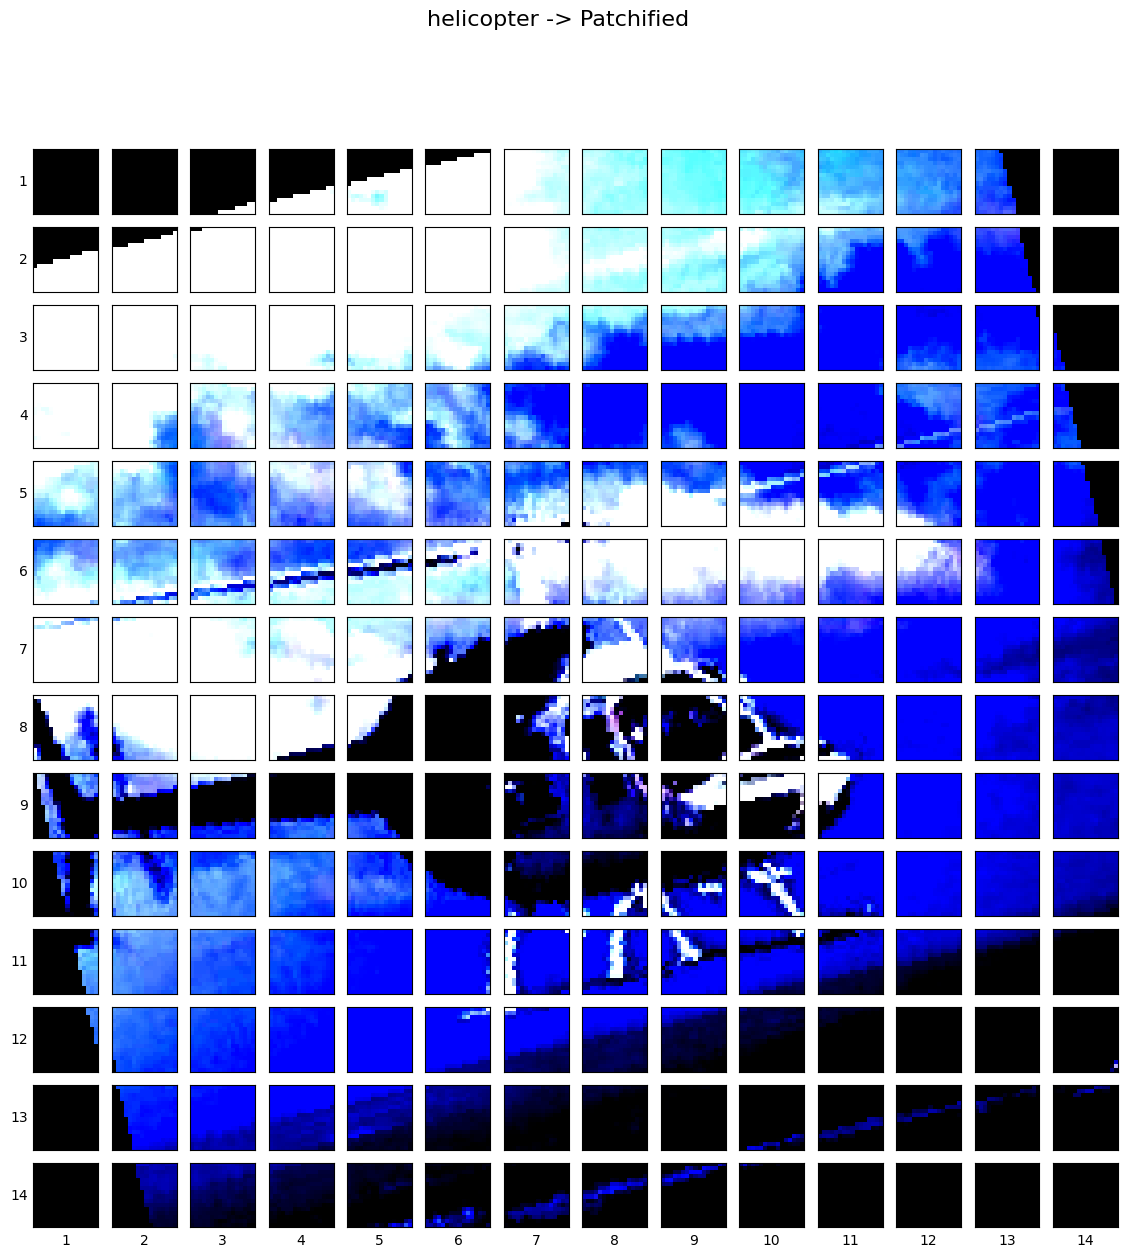

In [81]:
image_permuted = image.permute(1, 2, 0)
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

In [82]:
patch_size = 16

conv2d = nn.Conv2d(
    in_channels=3, # color channels
    out_channels=768, # embedding size
    kernel_size=patch_size,
    stride=patch_size,
    padding=0
)

In [83]:
image_conv = conv2d(image.unsqueeze(0))
print(image_conv.shape)

torch.Size([1, 768, 14, 14])


In [84]:
flatten = nn.Flatten(start_dim = 2, end_dim = 3)

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


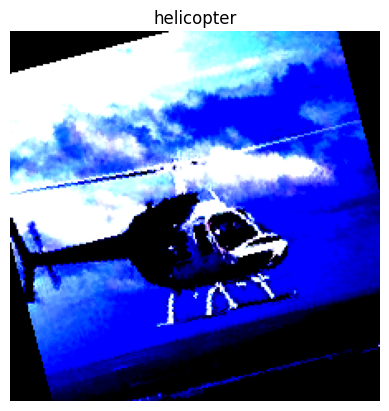

In [85]:
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [86]:
image_out_of_conv_flattened = flatten(image_out_of_conv)
image_out_of_conv_flattened.shape

torch.Size([1, 768, 196])

In [87]:
class PatchEmbedding(nn.Module):
  def __init__(self, in_channels = 3,
               out_channels = 768,
               patch_size = 16,
               embedding_size = 768):
    super().__init__()
    self.patcher = nn.Conv2d(
        in_channels = in_channels,
        out_channels = out_channels,
        kernel_size = patch_size,
        stride = patch_size,
        padding = 0
    )
    self.flatten = nn.Flatten(start_dim = 2, end_dim = 3)

  def forward(self, x):
    return self.flatten(self.patcher(x)).permute(0, 2, 1)

In [88]:
patchify = PatchEmbedding()

print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension on the 0th index, otherwise will error
print(f"Output patch embedding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


In [89]:
!pip install torchinfo

In [90]:
from torchinfo import summary

In [91]:
random_input_image = (1, 3, 224, 224)

summary(PatchEmbedding(),
         input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [92]:
print(patch_embedded_image)

tensor([[[ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
         [ 0.3950,  1.2707,  0.1789,  ...,  0.1653, -0.3970,  0.5984],
         ...,
         [ 0.4349,  0.8731,  0.9741,  ...,  0.0749, -0.0791,  0.2362],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956]]],
       grad_fn=<PermuteBackward0>)


In [93]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [94]:
batch_size = patch_embedded_image.shape[0]
dimension = patch_embedded_image.shape[-1]

class_token = nn.Parameter(torch.randn(batch_size, 1, dimension),
                           requires_grad=True)

# print first 10 example
print(class_token[:,:,10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[0.2588]], grad_fn=<SelectBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [95]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim = 1) # concat on first dimension
print(patch_embedded_image_with_class_embedding)    # (ilk satır farklı)

tensor([[[ 0.4936,  0.6781, -0.6542,  ..., -1.3779, -0.2032, -0.1806],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
         ...,
         [ 0.4349,  0.8731,  0.9741,  ...,  0.0749, -0.0791,  0.2362],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
         [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956]]],
       grad_fn=<CatBackward0>)


In [96]:
# learnable class token prepended!
print(f"shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


## Transformer Encoder

In [97]:
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape

(tensor([[[ 0.4936,  0.6781, -0.6542,  ..., -1.3779, -0.2032, -0.1806],
          [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
          [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
          ...,
          [ 0.4349,  0.8731,  0.9741,  ...,  0.0749, -0.0791,  0.2362],
          [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956],
          [ 0.3180,  0.8595,  0.9208,  ...,  0.0830, -0.0623,  0.1956]]],
        grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [98]:
num_of_patches = patch_embedded_image_with_class_embedding.shape[1]
embedding_dim = patch_embedded_image_with_class_embedding.shape[2]

pos_embedding = nn.Parameter(torch.randn(1,
                                         num_of_patches,
                                         embedding_dim,
                                         requires_grad=True))
print(pos_embedding[:,:10,:10])

tensor([[[-0.6599, -0.1068, -0.4637, -1.7291, -0.0842, -0.2730,  1.1315,
           0.1818, -0.5613, -0.6315],
         [-0.6381, -0.3711,  1.1524, -1.4285, -2.4330,  0.2507, -0.5943,
          -0.4056,  0.7249, -0.6463],
         [ 1.0748,  0.3955, -0.5569, -0.8708, -0.1601,  0.5064, -1.3326,
           0.4043, -0.0987,  1.2756],
         [-0.3702, -1.4124,  2.0760, -1.4516, -1.3400, -0.1473,  1.4896,
           0.9627, -1.3994,  0.5549],
         [ 1.2566, -0.3995, -0.0438, -0.7326,  0.5955, -0.5821, -1.0079,
           1.6664,  0.8990,  1.1234],
         [ 1.4360, -0.6442, -2.6139,  0.3476,  0.5988,  0.5619, -0.0671,
          -0.6758, -0.3953,  1.9813],
         [-0.3646, -0.3567, -0.7040,  0.6716, -1.8380, -1.3295,  0.7835,
           1.4285, -0.4937, -0.4084],
         [-0.4206, -0.0460, -0.9844, -1.5295,  0.3289,  0.1948, -0.9109,
          -0.4866,  0.0228,  2.0069],
         [-0.1597, -1.7269,  1.6473, -0.1363, -1.1881, -1.2906,  0.4854,
          -0.3177, -0.8297, -0.6286],
 

In [99]:
print(pos_embedding.shape)

torch.Size([1, 197, 768])


In [100]:
patch_pos_embedding = patch_embedded_image_with_class_embedding + pos_embedding
print(patch_pos_embedding)

tensor([[[-0.1663,  0.5713, -1.1179,  ..., -1.4353, -0.3086,  0.2686],
         [-0.3200,  0.4884,  2.0732,  ..., -1.1127, -0.6750,  1.3465],
         [ 1.3929,  1.2551,  0.3639,  ..., -2.0041,  0.4892, -0.7088],
         ...,
         [ 1.0773,  0.0362,  2.0732,  ..., -0.4775,  0.4056, -0.5239],
         [ 1.6018,  2.2858, -0.8370,  ..., -0.0420,  0.1126, -0.9088],
         [ 0.5851,  0.5655,  0.5403,  ...,  0.3552, -1.2964,  1.4850]]],
       grad_fn=<AddBackward0>)


In [101]:
print(patch_pos_embedding.shape)

torch.Size([1, 197, 768])


In [102]:
patch_size = 16

height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)

# create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels = 3,
                                       patch_size = patch_size,
                                       embedding_size = 768)

# pass image thru patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(patch_embedding.shape)

torch.Size([1, 196, 768])


In [103]:
# create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dim = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.randn(batch_size,1,embedding_dim), requires_grad=True)

# prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim = 1)
print(patch_embedding_class_token.shape)

torch.Size([1, 197, 768])


In [104]:
# create position embedding
num_of_patches = int((height * width) / patch_size**2)
pos_embedding = nn.Parameter(torch.randn(1,
                                         num_of_patches + 1,
                                         embedding_dim,
                                         requires_grad=True))
print(pos_embedding.shape)

torch.Size([1, 197, 768])


In [105]:
# add position embedding to patch embedding with class token
patch_pos_embedding = patch_embedding_class_token + pos_embedding
print(patch_pos_embedding.shape)

torch.Size([1, 197, 768])


In [106]:
class MultiheadSelfAttention(nn.Module):
  def __init__(self,
               embedding_dim = 768,
               num_heads = 12,
               dropout_rate = 0):
    super().__init__()

    # create Norm Layer (LN)
    self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)

    # create MSA Layer
    self.multihead_attn = nn.MultiheadAttention(embed_dim = embedding_dim,
                                   num_heads = num_heads,
                                   dropout = dropout_rate,
                                   batch_first = True)

  def forward(self, x):
    x = self.layer_norm(x)
    attention_output, _ = self.multihead_attn(query = x,
                                           key = x,
                                           value = x)
    return attention_output


In [107]:
msaBlock = MultiheadSelfAttention(embedding_dim=768,
                                  num_heads=12)
patch_image_through_msa_block = msaBlock(patch_pos_embedding)

print("Input shape of MSA block" , patch_pos_embedding.shape)
print("Output shape of MSA block" , patch_image_through_msa_block.shape)

Input shape of MSA block torch.Size([1, 197, 768])
Output shape of MSA block torch.Size([1, 197, 768])


## MLP

In [108]:
class MLP(nn.Module):
  def __init__(self,
               embedding_dim = 768,
               mlp_size = 3072,
               dropout = 0.1):

    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dim)

    self.mlp = nn.Sequential(
        nn.Linear(in_features = embedding_dim,
                  out_features = mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,
                  out_features=embedding_dim),
        nn.Dropout(dropout)
    )

  def forward(self, x):
    y = self.layer_norm(x)
    x = self.mlp(y)
    return x


In [109]:
mlp_block = MLP(embedding_dim = 768,
                mlp_size = 3072,
                dropout=0.1)
patched_image_through_mlp = mlp_block(patch_image_through_msa_block)
print("Input shape of MLP block" , patch_image_through_msa_block.shape)
print("Output shape of MLP block" , patched_image_through_mlp.shape)

Input shape of MLP block torch.Size([1, 197, 768])
Output shape of MLP block torch.Size([1, 197, 768])


In [110]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embedding_dim = 768,
               num_heads = 12,
               mlp_size = 3072,
               mlp_dropout = 0.1,
               attn_dropout = 0):
    super().__init__()
    self.msa_block = MultiheadSelfAttention(embedding_dim=embedding_dim,
                                            num_heads=num_heads,
                                            dropout_rate=attn_dropout)
    self.mlp_block = MLP(embedding_dim=embedding_dim,
                         mlp_size = mlp_size,
                         dropout = mlp_dropout)

  def forward(self, x):
    # create residual connection for msa block (add input to output)
    x = self.msa_block(x) + x

    # create residual connection for mlp block (add input to output)
    x = self.mlp_block(x) + x

    return x

In [111]:
# create an instance of transformer encoder block
transformer_encoder_block = TransformerEncoderBlock()

summary(model = transformer_encoder_block,
        input_size = (1, 197,768), # batchsize, numpatches, embedding_dim
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width = 20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiheadSelfAttention (msa_block)               [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLP (mlp_block)                                  [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [ ]:
class ViT(nn.Module):
  def __init__(self,
               img_size = 224,
               in_channels = 3,
               patch_size = 16,
               num_transformer_layers = 12,
               embedding_dim = 768,
               mlp_size = 3072,
               num_heads = 12,
               attn_dropout = 0,
               mlp_dropout = 0.1,
               embedding_dropout = 0.1,
               num_classes = 101):
    super().__init__()

    # Make the image size is divisible by the patch size
    assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size:{img_size}, patch size: {patch_size}."

    self.num_patches = (img_size * img_size) // patch_size ** 2
    self.class_embedding = nn.Parameter(data = torch.randn(1, 1, embedding_dim),
                                        requires_grad = True)
    self.position_embedding = nn.Parameter(data = torch.randn(1, self.num_patches + 1, embedding_dim),
                                          requires_grad = True)
    self.embedding_dropout = nn.Dropout(embedding_dropout)

    self.patch_embedding_layer = PatchEmbedding(in_channels = in_channels,
                                                patch_size = patch_size,
                                                embedding_size = embedding_dim)

    # Note: The "*" means "all"
    self.transformer_encoder = nn.Sequential(
        *[TransformerEncoderBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout
        ) for _ in range(num_transformer_layers)]
    )

    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape = embedding_dim),
        nn.Linear(in_features = embedding_dim,
                  out_features = num_classes)
    )

  def forward(self, x):
    # get batch size
    batch_size = x.shape[0]

    # create class token embedding and expand it to match vatch size
    class_token = self.class_embedding.expand(batch_size, -1,-1)  # -1 means to infer the dimension (try this line on its own)

    # create patch embedding
    x = self.patch_embedding_layer(x) # Corrected from self.patch_embedding(x)

    # concat class embed and patch embed
    x = torch.cat((class_token, x),dim=1)

    # add pos embedding to patch embed
    x = x + self.position_embedding

    # dropout
    x = self.embedding_dropout(x)

    x = self.transformer_encoder(x)
    x = self.classifier(x[:,0])  # run on each sample in a batch at index 0

    return x

In [112]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [118]:
vit = ViT(num_classes = len(class_names)).to(device)

optimizer = torch.optim.Adam(params = vit.parameters(),
                             lr = 3e-3,   # 3 * 10 ^ (-1)
                             weight_decay = 0.3)

loss_fn = torch.nn.CrossEntropyLoss()

In [119]:
results = train(model = vit,
                train_dataloader=train_dataloader,
                test_dataloader = test_dataloader,
                optimizer = optimizer,
                loss_fn = loss_fn,
                epochs = 5,
                device = device
                )

Epoch: 1 | train_loss: 4.5113 | train_acc: 0.0869 | test_loss: 4.2894 | test_acc: 0.0861
Epoch: 2 | train_loss: 4.2550 | train_acc: 0.0935 | test_loss: 4.2503 | test_acc: 0.0861
Epoch: 3 | train_loss: 4.2720 | train_acc: 0.0957 | test_loss: 4.2501 | test_acc: 0.0861


KeyboardInterrupt: 

In [114]:
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT

pretrained_vit = torchvision.models.vit_b_16(weights = pretrained_vit_weights).to(device)

for parameter in pretrained_vit.parameters():
  parameter.requires_grad = False

pretrained_vit.heads = nn.Linear(in_features = 768,
                                 out_features = len(class_names)).to(device)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 57.4MB/s]


In [ ]:
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

In [116]:
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()


pretrained_vit_results = train(model=pretrained_vit,
                                      train_dataloader=train_dataloader,
                                      test_dataloader=test_dataloader,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=3,
                                      device=device)

Epoch: 1 | train_loss: 1.0907 | train_acc: 0.8217 | test_loss: 0.3286 | test_acc: 0.9222
Epoch: 2 | train_loss: 0.2243 | train_acc: 0.9502 | test_loss: 0.2373 | test_acc: 0.9409
Epoch: 3 | train_loss: 0.1396 | train_acc: 0.9644 | test_loss: 0.2391 | test_acc: 0.9230


In [146]:
image_path = "data/deer.jpg"

In [147]:
# we should spesify the float32 dtype here like this
single_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

In [148]:

# then convert numbers into [0,1] by dividing it to 255
single_image = single_image / 255

In [149]:
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    #transforms.ToTensor(),
])

In [150]:

single_image = manual_transforms(single_image)

In [151]:

single_image.shape

torch.Size([3, 224, 224])

In [152]:

single_image.unsqueeze(dim=0).shape

torch.Size([1, 3, 224, 224])

In [153]:
single_image = single_image.unsqueeze(dim=0).to(device)

In [154]:
pretrained_vit.eval()
with torch.inference_mode():
    logits = pretrained_vit(single_image)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class:", class_names[pred_idx])

Predicted class: gerenuk


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

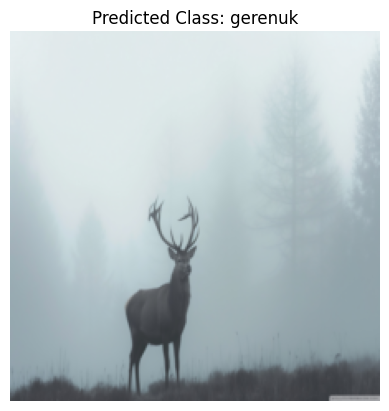

In [155]:
plt.imshow(single_image.squeeze(0).permute(1, 2, 0).cpu())
plt.title(f'Predicted Class: {class_names[pred_idx]}')
plt.axis(False)

In [156]:
print(class_names)  # there is no deer

['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass', 'beaver', 'binocular', 'bonsai', 'brain', 'brontosaurus', 'buddha', 'butterfly', 'camera', 'cannon', 'car_side', 'ceiling_fan', 'cellphone', 'chair', 'chandelier', 'cougar_body', 'cougar_face', 'crab', 'crayfish', 'crocodile', 'crocodile_head', 'cup', 'dalmatian', 'dollar_bill', 'dolphin', 'dragonfly', 'electric_guitar', 'elephant', 'emu', 'euphonium', 'ewer', 'ferry', 'flamingo', 'flamingo_head', 'garfield', 'gerenuk', 'gramophone', 'grand_piano', 'hawksbill', 'headphone', 'hedgehog', 'helicopter', 'ibis', 'inline_skate', 'joshua_tree', 'kangaroo', 'ketch', 'lamp', 'laptop', 'llama', 'lobster', 'lotus', 'mandolin', 'mayfly', 'menorah', 'metronome', 'minaret', 'nautilus', 'octopus', 'okapi', 'pagoda', 'panda', 'pigeon', 'pizza', 'platypus', 'pyramid', 'revolver', 'rhino', 'rooster', 'saxophone', 'schooner', 'scissors', 'scorpion', 'sea_horse', 'snoopy', 'soccer_ball', 'stapler

In [157]:
airplane = "data/airplane.jpg"

In [158]:
# Load the airplane image
single_image_airplane = torchvision.io.read_image(str(airplane)).type(torch.float32)

# Normalize to [0, 1]
single_image_airplane = single_image_airplane / 255

In [159]:
# Apply manual transforms (resize)
single_image_airplane = manual_transforms(single_image_airplane)

In [160]:
# Add batch dimension and move to device
single_image_airplane = single_image_airplane.unsqueeze(dim=0).to(device)

In [161]:
# Make prediction with the pretrained ViT model
pretrained_vit.eval()
with torch.inference_mode():
    logits_airplane = pretrained_vit(single_image_airplane)
    probs_airplane = torch.softmax(logits_airplane, dim=1)
    pred_idx_airplane = probs_airplane.argmax(dim=1).item()

print("Predicted class:", class_names[pred_idx_airplane])

Predicted class: airplanes


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

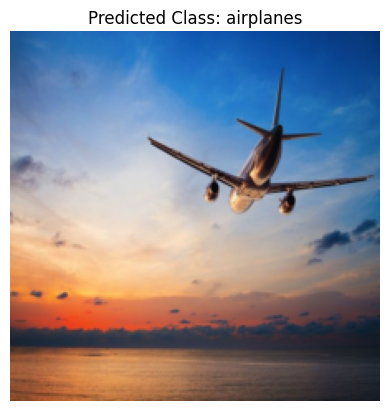

In [162]:
# Display the airplane image with prediction
plt.imshow(single_image_airplane.squeeze(0).permute(1, 2, 0).cpu())
plt.title(f'Predicted Class: {class_names[pred_idx_airplane]}')
plt.axis(False)